In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
normal = os.listdir('Normal/')
tuber = os.listdir('Tuberculosis/')
len(normal)


3500

In [3]:
len(tuber)

700

In [10]:
sizes = []
for img_name in os.listdir("Normal"):
    img_path = os.path.join("Normal", img_name)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    sizes.append((w, h))

print("Max_size:", min(sizes))
print("Min_size:", max(sizes))

Max_size: (512, 512)
Min_size: (512, 512)


In [11]:
sizes = []
for img_name in os.listdir("Tuberculosis"):
    img_path = os.path.join("Tuberculosis", img_name)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    sizes.append((w, h))

print("Max_size:", min(sizes))
print("Min_size:", max(sizes))

Max_size: (512, 512)
Min_size: (512, 512)


In [4]:
labels = {
    'Normal': 0,
    'Tuberculosis': 1
}

X_tr = []
y_tr = []

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

Rent_copy = 4

for i in os.listdir('.'):

    if i not in labels:
        continue

    class_path = i

    try:
        for j in os.listdir(class_path):

            image_path = os.path.join(class_path, j)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue
            image = cv2.resize(image, (256, 256))
            image = image.astype("float32") / 255.0
            image = image.reshape(256,256,1)
            X_tr.append(image)
            y_tr.append(labels[i])
            if i == "Tuberculosis":

                image_exp = np.expand_dims(image, 0)
                aug_iter = datagen.flow(image_exp, batch_size=1)

                for _ in range(Rent_copy):
                    aug_image = next(aug_iter)[0]
                    X_tr.append(aug_image)
                    y_tr.append(labels[i])

    except Exception as e:
        print(f"Error {i}/{j}: {e}")
        continue


X_tr = np.array(X_tr, dtype="float32")
y_tr = np.array(y_tr)

print(f"len(X_tr) = {X_tr.shape[0]}")
print(f"len(y_tr) = {y_tr.shape[0]}")

len(X_tr) = 7000
len(y_tr) = 7000


In [8]:
from keras.utils import to_categorical
y_tr = to_categorical(y_tr,num_classes=2)

In [10]:
from sklearn.utils import shuffle

X_tr, y_tr = shuffle(X_tr, y_tr, random_state=42)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_tr, y_tr, test_size=0.30, random_state=42)

In [13]:
X_train.shape

(4900, 256, 256, 1)

In [44]:
from keras import Sequential
from keras.layers import Dense, MaxPooling2D, Conv2D, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam, RMSprop

In [45]:
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=120, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(units=100, activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(units=60, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(units=1, activation='sigmoid'))

In [46]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [47]:
y_train = np.argmax(y_train, axis=1)
y_test = np.argmax(y_test, axis=1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [48]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30)

Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 55s 352ms/step - accuracy: 0.7765 - loss: 0.4706 - val_accuracy: 0.7929 - val_loss: 0.4098
Epoch 2/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 352ms/step - accuracy: 0.8810 - loss: 0.2899 - val_accuracy: 0.8952 - val_loss: 0.2589
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 352ms/step - accuracy: 0.9071 - loss: 0.2375 - val_accuracy: 0.9295 - val_loss: 0.2049
Epoch 4/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 353ms/step - accuracy: 0.9214 - loss: 0.2096 - val_accuracy: 0.9148 - val_loss: 0.2308
Epoch 5/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 353ms/step - accuracy: 0.9365 - loss: 0.1793 - val_accuracy: 0.9595 - val_loss: 0.1119
Epoch 6/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 56s 362ms/step - accuracy: 0.9394 - loss: 0.1616 - val_accuracy: 0.9700 - val_loss: 0.0992
Epoch 7/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 55s 355ms/step - accuracy: 0.9553 - loss: 0.1304 - val_accuracy: 0.9648 - val_loss: 0.1034
Epoch 8/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 351ms/step - accuracy: 0.9514 - loss: 0

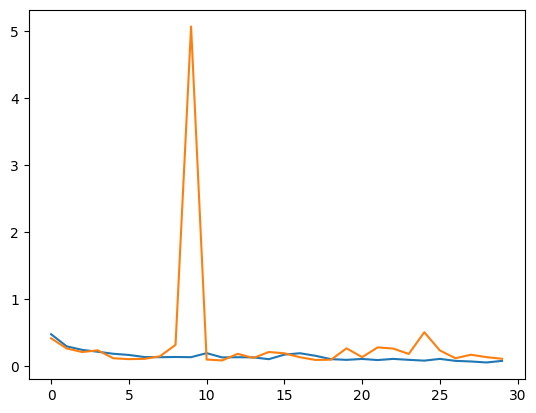

In [56]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

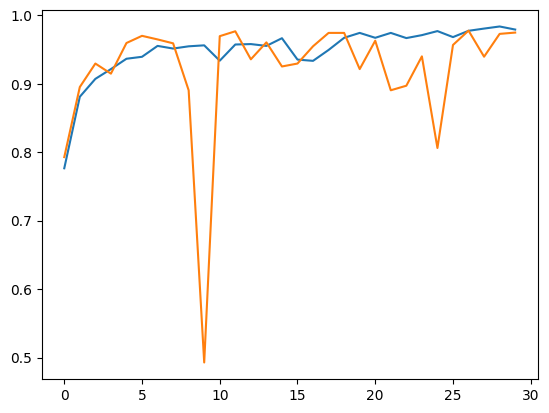

In [57]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [91]:
test_image = mpimg.imread('410a0505b04d2a5c839358e61a544af4e959d65e09bd5aba7018094519377867_big_gallery.jpeg')

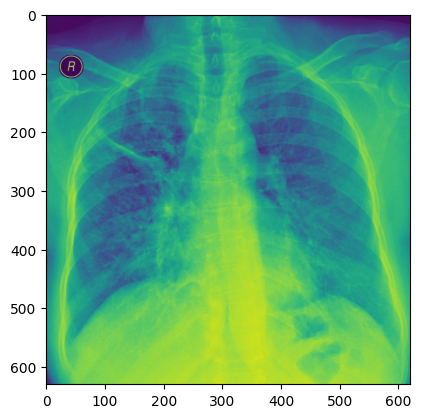

In [92]:
plt.imshow(test_image)

In [93]:
test_image.shape

(630, 621)

In [94]:
test_image = cv2.resize(test_image, (256,256))
test_image = test_image.astype("float32") / 255.0
test_image = test_image.reshape(256,256,1)
test_image = np.expand_dims(test_image, axis=0)
pred = model.predict(test_image)

print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction: [[0.9468546]]


In [95]:
if pred[0][0] > 0.5:
    print("Tuberculosis")
else:
    print("Normal")

Tuberculosis


In [122]:
test_image2 = mpimg.imread('images.jpg')

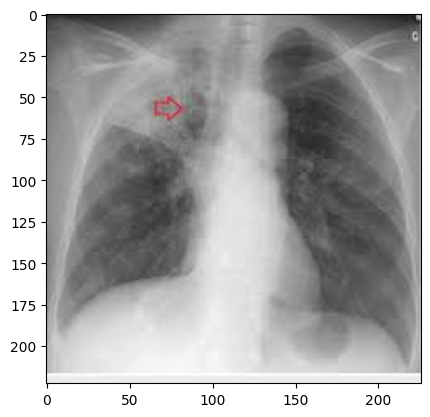

In [123]:
plt.imshow(test_image2)

In [127]:
test_image2.shape

(1, 256, 256, 1)

In [125]:
test_image2 = cv2.resize(test_image2, (256,256))
test_image2 = cv2.cvtColor(test_image2, cv2.COLOR_RGB2GRAY)
test_image2 = test_image2.astype("float32") / 255.0
test_image2 = np.expand_dims(test_image2, axis=-1)
test_image2 = np.expand_dims(test_image2, axis=0)
pred = model.predict(test_image2)
print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: [[0.06837889]]


In [128]:
if pred[0][0] > 0.5:
    print("Tuberculosis")
else:
    print("Normal")

Normal


In [129]:
test_image3 = mpimg.imread('627a8651ef5ce669f7fbb2678f56feec.jpg')

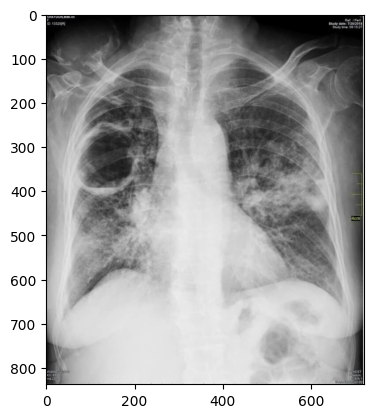

In [130]:
plt.imshow(test_image3)

In [131]:
test_image3.shape

(838, 720, 3)

In [132]:
test_image3 = cv2.resize(test_image3, (256,256))
test_image3 = cv2.cvtColor(test_image3, cv2.COLOR_RGB2GRAY)
test_image3 = test_image3.astype("float32") / 255.0
test_image3 = np.expand_dims(test_image3, axis=-1)
test_image3 = np.expand_dims(test_image3, axis=0)
pred = model.predict(test_image3)
print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: [[0.9824957]]


In [133]:
if pred[0][0] > 0.5:
    print("Tuberculosis")
else:
    print("Normal")

Tuberculosis
